In [28]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import boxcox

In [29]:
data = pd.read_csv(r"C:\Users\ankit\Downloads\Student_Performance.csv")

In [30]:
data

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [31]:
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [32]:
data.shape

(10000, 6)

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [34]:
data.dtypes

Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities           object
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object

In [35]:

data.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [36]:
data.nunique()

Hours Studied                        9
Previous Scores                     60
Extracurricular Activities           2
Sleep Hours                          6
Sample Question Papers Practiced    10
Performance Index                   91
dtype: int64

In [37]:
data.drop_duplicates()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [38]:
data.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [39]:
data.tail()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0
9999,7,74,No,8,1,64.0


In [40]:
data.duplicated().sum()

np.int64(127)

In [41]:
data.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [42]:
data.dropna(inplace= True)
data

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [43]:
data.drop(["Extracurricular Activities", "Sleep Hours"], axis = 1)

,Hours Studied,Previous Scores,Sample Question Papers Practiced,Performance Index
0,7,99,1,91.0
1,4,82,2,65.0
2,8,51,2,45.0
3,5,52,2,36.0
4,7,75,5,66.0
...,...,...,...,...
9995,1,49,2,23.0
9996,7,64,5,58.0
9997,6,83,5,74.0
9998,9,97,0,95.0


In [44]:
data["Performance Index"].value_counts()

Performance Index
67.0     187
45.0     185
56.0     181
49.0     181
40.0     180
        ... 
14.0       7
99.0       6
11.0       5
100.0      3
10.0       1
Name: count, Length: 91, dtype: int64

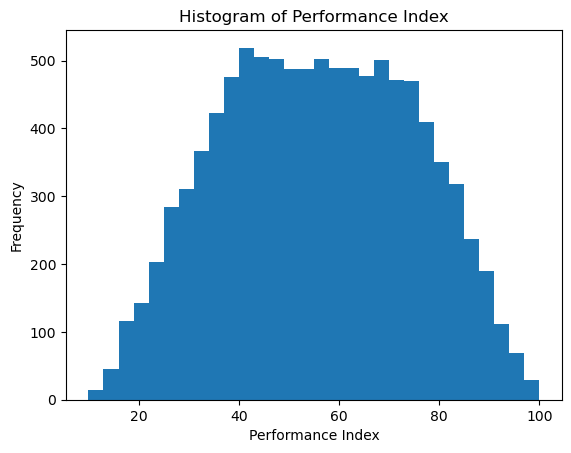

In [45]:
plt.figure()
plt.hist(data['Performance Index'], bins=30)
plt.title("Histogram of Performance Index")
plt.xlabel("Performance Index")
plt.ylabel("Frequency")
plt.show()

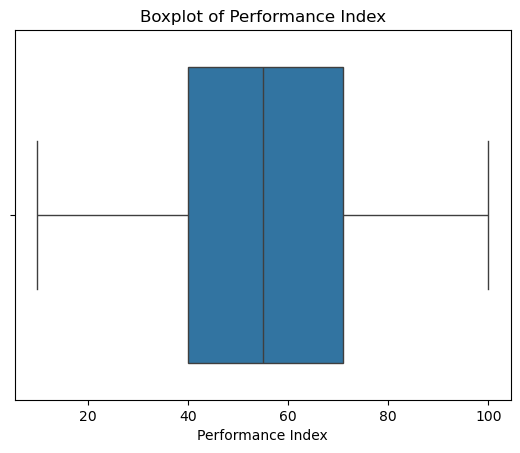

In [46]:
plt.figure()
sns.boxplot(x=data["Performance Index"])
plt.title("Boxplot of Performance Index")
plt.show()

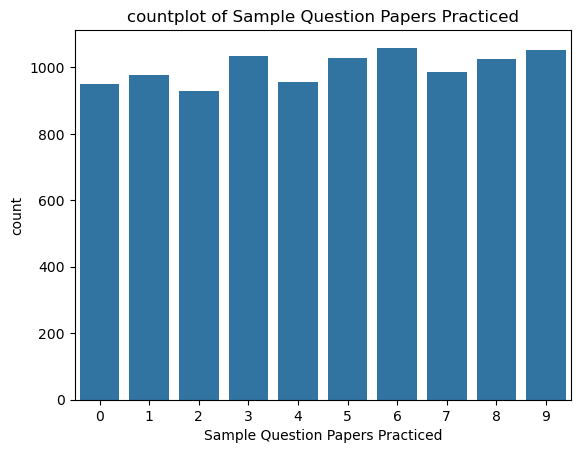

In [47]:
plt.figure()
sns.countplot(x=data["Sample Question Papers Practiced"])
plt.title("countplot of Sample Question Papers Practiced")
plt.show()


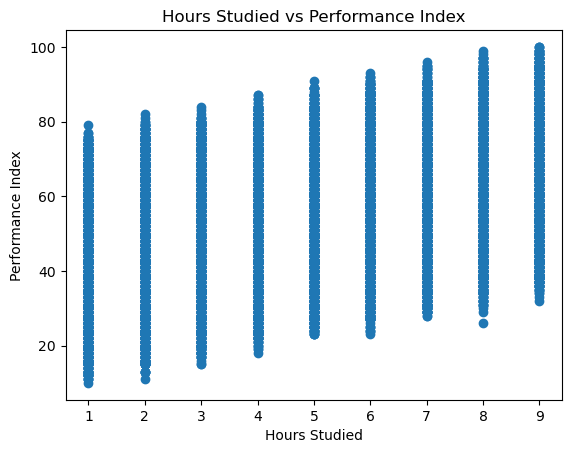

In [48]:
plt.figure()
plt.scatter(data["Hours Studied"],data["Performance Index"])
plt.title("Hours Studied vs Performance Index")
plt.xlabel("Hours Studied")
plt.ylabel("Performance Index")
plt.show()

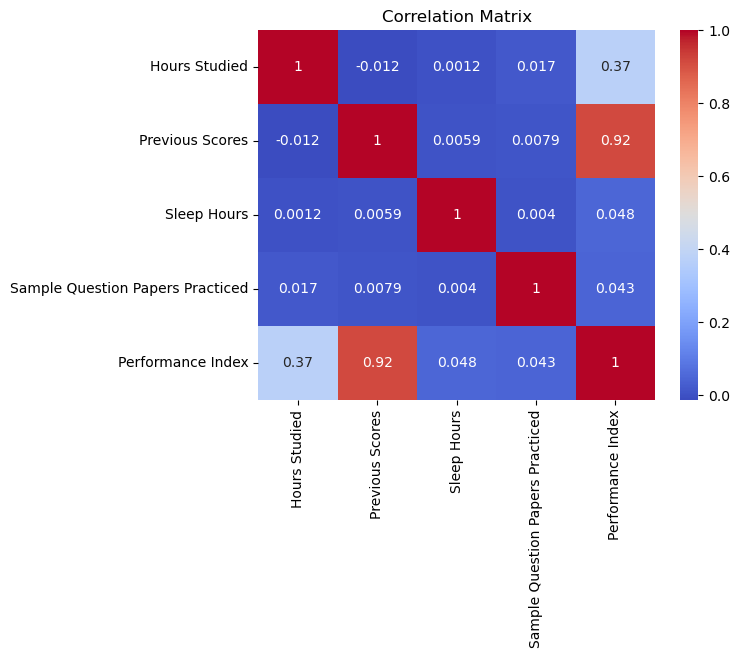

In [49]:
plt.figure()
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [51]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import boxcox

In [52]:
data = pd.read_csv(r"C:\Users\ankit\Downloads\Student_Performance.csv")

In [54]:
print("Skewness of Performance Index:", data['Performance Index'].skew())

Skewness of Performance Index: -0.001740027307220109


In [56]:
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [58]:
data.shape

(10000, 6)

In [60]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [62]:
data.columns = data.columns.str.strip()
data

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [64]:
data.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [65]:
num_cols = data.select_dtypes(include='number').columns
data[num_cols] = data[num_cols].fillna(data[num_cols].median())
data

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [66]:
data['Extracurricular Activities'] = data['Extracurricular Activities'].map({'Yes':1, 'No':0})
data

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,1,4,2,23.0
9996,7,64,1,8,5,58.0
9997,6,83,1,8,5,74.0
9998,9,97,1,7,0,95.0


In [67]:
data.drop(["Extracurricular Activities", "Sleep Hours"], axis = 1)

,Hours Studied,Previous Scores,Sample Question Papers Practiced,Performance Index
0,7,99,1,91.0
1,4,82,2,65.0
2,8,51,2,45.0
3,5,52,2,36.0
4,7,75,5,66.0
...,...,...,...,...
9995,1,49,2,23.0
9996,7,64,5,58.0
9997,6,83,5,74.0
9998,9,97,0,95.0


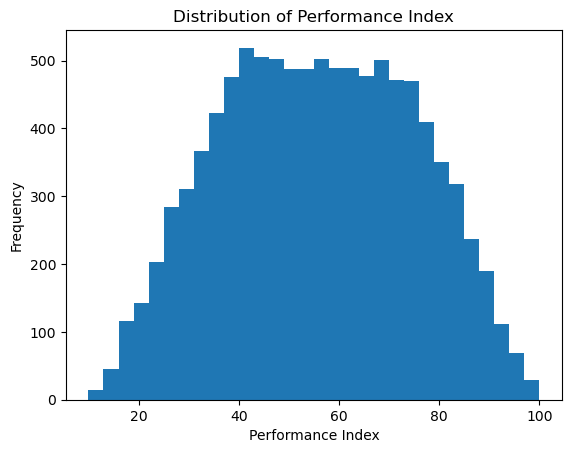

In [69]:
plt.figure()
plt.hist(data['Performance Index'], bins=30)
plt.title('Distribution of Performance Index')
plt.xlabel('Performance Index')
plt.ylabel('Frequency')
plt.show()

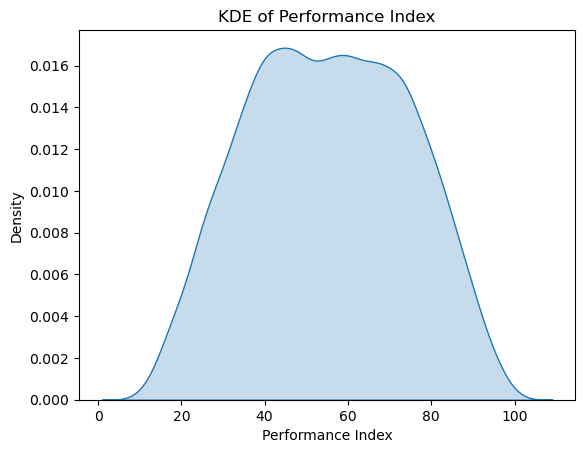

In [70]:
plt.figure()
sns.kdeplot(data['Performance Index'], fill=True)
plt.title('KDE of Performance Index')
plt.show()

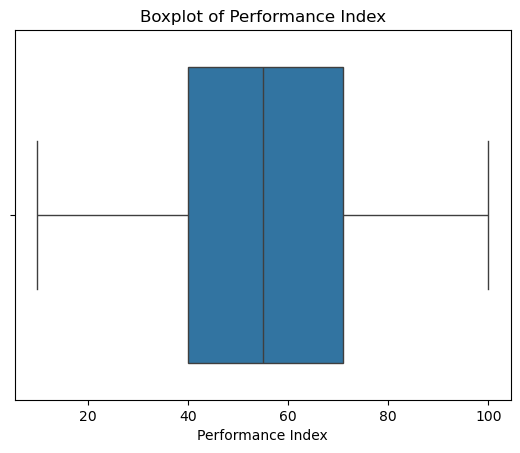

In [71]:
plt.figure()
sns.boxplot(x=data['Performance Index'])
plt.title('Boxplot of Performance Index')
plt.show()

In [72]:
data['Performance Index'].skew()

np.float64(-0.001740027307220109)

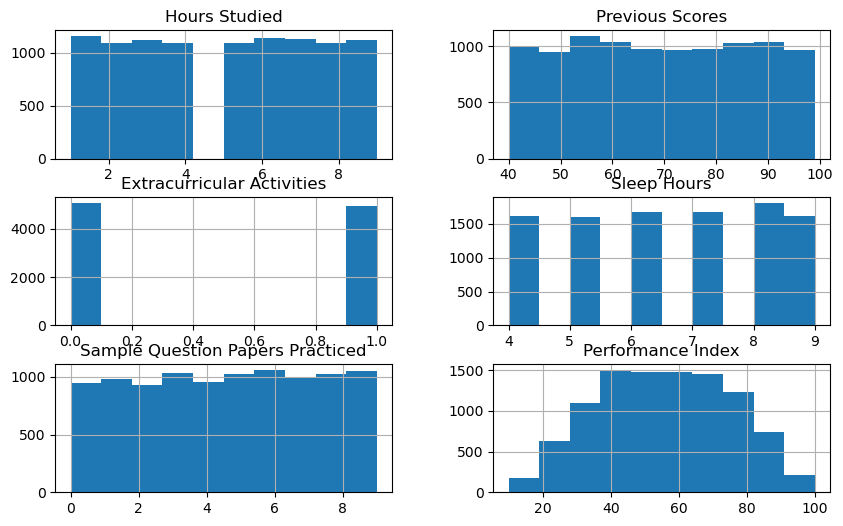

In [73]:
data.hist(figsize=(10,6))
plt.show()

In [74]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [75]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [76]:
X = data[['Hours Studied', 'Previous Scores','Sample Question Papers Practiced']]
y = data['Performance Index']

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [78]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [79]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [80]:
y_pred_lr = lr.predict(X_test)

In [81]:
print("Linear Regression R2 Score:", r2_score(y_test, y_pred_lr))
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))

Linear Regression R2 Score: 0.9868792226097673
Linear Regression MSE: 4.862364811169535


In [82]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [83]:
pr = LinearRegression()
pr.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [84]:
y_pred_pr = pr.predict(X_test_poly)

In [85]:
print("Polynomial Regression R2 Score:", r2_score(y_test, y_pred_pr))
print("Polynomial Regression MSE:", mean_squared_error(y_test, y_pred_pr))

Polynomial Regression R2 Score: 0.9868854045425491
Polynomial Regression MSE: 4.86007387889249


In [87]:
from sklearn.preprocessing import PolynomialFeatures
rom sklearn.linear_model import linearRegression

polynomial = PolynomialFeatures(degree=2)
poly_features = polynomial.fit_transform(X_train)
model = LinearRegression()
model.fit(poly_features , y_train)

In [93]:
model.coef_ , model.intercept_

(array([ 0.00000000e+00,  7.40858585e+00,  1.76377763e+01,  5.48321992e-01,
         3.60234366e-02, -6.21865394e-03, -7.23036002e-03, -2.58314062e-02,
        -1.93227436e-02,  3.59433432e-03]),
 np.float64(55.29795556801924))